In [14]:
from PIL import Image

name = "convallaria_512"

def png_to_5bit_greyscale_c_array(input_png, output_c):
    # Open the PNG file
    img = Image.open(input_png).convert('RGB')  # Ensure RGB format
    width, height = img.size
    pixels = img.load()
    
    if width != height:
        f.write("error: image is not square")
        return

    # Open the output .c file
    with open(output_c, 'w') as f:
        f.write("// Auto-generated C array from PNG\n")
        f.write("#include <stdint.h>\n\n")
        f.write(f"const uint32_t {name}")
        f.write("[] = {\n")
        
        # Process each pixel
        for y in range(height):
            for x in range(width):
                # Get RGB pixel value
                r, g, b = pixels[x, y]

                # Convert RGB to greyscale (luminosity method)
                grey = int(0.299 * r + 0.587 * g + 0.114 * b)

                # Scale to 5 bits (0-31)
                grey_5bit = grey >> 3  # Divide by 8 to fit into 5 bits

                # Pack into 32-bit word (only 5 LSBs set)
                word = grey_5bit & 0x1F  # Mask to ensure only 5 LSBs are used

                # Write as hex value to the .c file
                f.write(f"    0x{word:08X},\n")

        f.write("};\n")
        #f.write(f"const size_t binary_data_size = {width};\n")

# Example usage
input_png = f"{name}.png"
output_c = f"{name}.h"
png_to_5bit_greyscale_c_array(input_png, output_c)


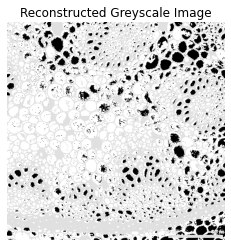

In [16]:
import ipdb
import numpy as np
import matplotlib.pyplot as plt

def read_c_array_to_image(c_file_path, output_image_path=None):
    # Read the C file and extract the data
    with open(c_file_path, 'r') as f:
        lines = f.readlines()

    # Extract the array values
    data = []
    for line in lines:
        if line.startswith("    0x"):
            hex_value = line.split("0x")[1].split(",")[0]
            data.append(int(hex_value, 16))

    # Extract the size (last line)
    size_line = lines[-1]
    #ipdb.set_trace()
    size = int(name.split("_")[1].strip(".png"))
    #size = int(size_line.split("=")[1].strip().rstrip(";"))

    # Reshape the data into a square image
    assert len(data) == size * size, "Data length does not match size*size"
    image_data = np.array(data, dtype=np.uint8)
    image_data = image_data.reshape((size, size))

    # Scale 5-bit to 8-bit for display
    image_data = (image_data * 255) // 31

    # Display the image
    plt.imshow(image_data, cmap='gray')
    plt.title("Reconstructed Greyscale Image")
    plt.axis('off')
    plt.show()

    # Optionally save the image
    if output_image_path:
        plt.imsave(output_image_path, image_data, cmap='gray')

# Example usage
c_file_path = f"{name}.h"
read_c_array_to_image(c_file_path, output_image_path=f"{name}_reconstructed.png")
